<a href="https://colab.research.google.com/github/anushka-singh0611/Pituitary_model.deployment/blob/main/Pituitary_model_deployment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pituitary Tumor Segmentation Using U-Net on MRI Images

In [ ]:
# PROJECT SETUP

from google.colab import drive
drive.mount('/content/drive')

import os

dataset_path = "/content/drive/MyDrive/Pituitary_tumor/segmentation_task"

train_images = os.path.join(dataset_path, "train", "images")
train_masks = os.path.join(dataset_path, "train", "masks")

test_images = os.path.join(dataset_path, "test", "images")
test_masks = os.path.join(dataset_path, "test", "masks")

print("✅ Dataset Loaded Successfully!")
print(os.listdir(dataset_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset Loaded Successfully!
['test', 'train']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

dataset_path = "/content/drive/MyDrive/Pituitary_tumor/segmentation_task"

train_images = dataset_path + "/train/images"
train_masks = dataset_path + "/train/masks"

test_images = dataset_path + "/test/images"
test_masks = dataset_path + "/test/masks"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print("Training Images:", len(os.listdir(train_images)))
print("Training Masks :", len(os.listdir(train_masks)))

print("Testing Images :", len(os.listdir(test_images)))
print("Testing Masks  :", len(os.listdir(test_masks)))

Training Images: 3933
Training Masks : 3934
Testing Images : 860
Testing Masks  : 859


In [ ]:
# 1 : INSTALL REQUIRED LIBRARIES

!pip install -q segmentation-models-pytorch
!pip install -q albumentations
!pip install -q opencv-python
!pip install -q torchmetrics

In [ ]:
# 2 : IMPORT LIBRARIES

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp

from sklearn.model_selection import train_test_split

from torchmetrics.classification import BinaryJaccardIndex

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'sample_data']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 3 : VERIFY DATASET
import os

dataset_path = "/content/drive/MyDrive/Pituitary_tumor/segmentation_task"

print("Dataset Contents:")
print(os.listdir(dataset_path))

print("\nTrain Folder:")
print(os.listdir(dataset_path + "/train"))

print("\nTest Folder:")
print(os.listdir(dataset_path + "/test"))

Dataset Contents:
['test', 'train']

Train Folder:
['images', 'masks']

Test Folder:
['images', 'masks']


In [ ]:
# ==========================================
# BLOCK 4 : COUNT DATA
# ==========================================

train_images = "/content/drive/MyDrive/Pituitary_tumor/segmentation_task/train/images"
train_masks = "/content/drive/MyDrive/Pituitary_tumor/segmentation_task/train/masks"

test_images = "/content/drive/MyDrive/Pituitary_tumor/segmentation_task/test/images"
test_masks = "/content/drive/MyDrive/Pituitary_tumor/segmentation_task/test/masks"

print("Training Images :", len(os.listdir(train_images)))
print("Training Masks  :", len(os.listdir(train_masks)))

print("Testing Images  :", len(os.listdir(test_images)))
print("Testing Masks   :", len(os.listdir(test_masks)))

Training Images : 3933
Training Masks  : 3934
Testing Images  : 860
Testing Masks   : 859


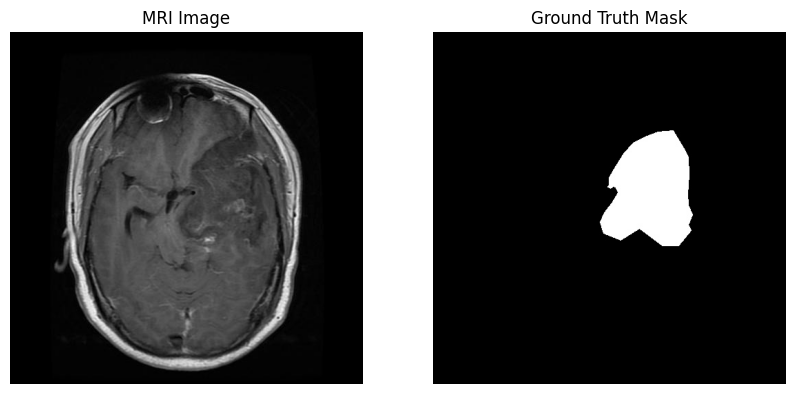

Image Shape : (512, 512, 3)
Mask Shape  : (512, 512)


In [ ]:
# BLOCK 5 : DISPLAY MRI IMAGE & MASK

import cv2
import matplotlib.pyplot as plt
import os

# Get sorted file names
image_files = sorted(os.listdir(train_images))
mask_files = sorted(os.listdir(train_masks))

# Select the first image
index = 0

image_path = os.path.join(train_images, image_files[index])
mask_path = os.path.join(train_masks, mask_files[index])

# Read image and mask
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# Display
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

print("Image Shape :", image.shape)
print("Mask Shape  :", mask.shape)

In [ ]:
# BLOCK 6 : PREPROCESSING
import cv2
import torch
import numpy as np

IMG_SIZE = 256

# Resize image
image_resized = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

# Resize mask
mask_resized = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

# Normalize image
image_resized = image_resized / 255.0

# Convert mask to binary (0 = background, 1 = tumor)
mask_resized = (mask_resized > 127).astype(np.float32)

# Convert to tensors
image_tensor = torch.tensor(image_resized, dtype=torch.float32).permute(2, 0, 1)
mask_tensor = torch.tensor(mask_resized, dtype=torch.float32).unsqueeze(0)

print("Image Tensor Shape :", image_tensor.shape)
print("Mask Tensor Shape  :", mask_tensor.shape)

print("Image Min :", image_tensor.min().item())
print("Image Max :", image_tensor.max().item())

print("Mask Unique Values :", torch.unique(mask_tensor))

Image Tensor Shape : torch.Size([3, 256, 256])
Mask Tensor Shape  : torch.Size([1, 256, 256])
Image Min : 0.0
Image Max : 0.9490196108818054
Mask Unique Values : tensor([0., 1.])


In [ ]:
# BLOCK 7 : CUSTOM DATASET
from torch.utils.data import Dataset
import cv2
import os
import torch
import numpy as np

class PituitaryDataset(Dataset):

    def __init__(self, image_dir, mask_dir, img_size=256):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.img_size = img_size

        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):

        return len(self.images)

    def __getitem__(self, index):

        image_path = os.path.join(self.image_dir, self.images[index])
        mask_path = os.path.join(self.mask_dir, self.masks[index])

        # Read Image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Read Mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Resize
        image = cv2.resize(image, (self.img_size, self.img_size))
        mask = cv2.resize(mask, (self.img_size, self.img_size),
                          interpolation=cv2.INTER_NEAREST)

        # Normalize
        image = image / 255.0

        # Binary Mask
        mask = (mask > 127).astype(np.float32)

        # Convert to Tensor
        image = torch.tensor(image, dtype=torch.float32).permute(2,0,1)

        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask

In [ ]:
# BLOCK 8 : CREATE DATASETS

train_dataset = PituitaryDataset(train_images, train_masks)
test_dataset = PituitaryDataset(test_images, test_masks)

print("Training Samples:", len(train_dataset))
print("Testing Samples :", len(test_dataset))

Training Samples: 3933
Testing Samples : 860


In [ ]:
# BLOCK 9 : VERIFY DATASET

image, mask = train_dataset[0]

print("Image Shape:", image.shape)
print("Mask Shape :", mask.shape)

Image Shape: torch.Size([3, 256, 256])
Mask Shape : torch.Size([1, 256, 256])


In [ ]:
# BLOCK 11 : DATALOADER
from torch.utils.data import DataLoader

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

print("✅ DataLoaders Created Successfully!")

✅ DataLoaders Created Successfully!


In [ ]:
# BLOCK 12 : BUILD U-NET MODEL
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder
        self.down1 = DoubleConv(3,64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64,128)
        self.pool2 = nn.MaxPool2d(2)

        # Bottleneck
        self.bridge = DoubleConv(128,256)

        # Decoder
        self.up1 = nn.ConvTranspose2d(256,128,kernel_size=2,stride=2)
        self.conv1 = DoubleConv(256,128)

        self.up2 = nn.ConvTranspose2d(128,64,kernel_size=2,stride=2)
        self.conv2 = DoubleConv(128,64)

        # Output Layer
        self.final = nn.Conv2d(64,1,kernel_size=1)

    def forward(self,x):

        # Encoder
        x1 = self.down1(x)
        p1 = self.pool1(x1)

        x2 = self.down2(p1)
        p2 = self.pool2(x2)

        # Bridge
        b = self.bridge(p2)

        # Decoder
        u1 = self.up1(b)
        u1 = torch.cat([u1,x2],dim=1)
        u1 = self.conv1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2,x1],dim=1)
        u2 = self.conv2(u2)

        return self.final(u2)

In [ ]:
# BLOCK 13 : CREATE MODEL
model = UNet()

print(model)

UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bridge): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  

In [ ]:
# BLOCK 14 : LOSS FUNCTION, OPTIMIZER & DEVICE

import torch
import torch.nn as nn
import torch.optim as optim

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device
model = model.to(device)

# Loss Function
loss_function = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Device:", device)
print("Loss Function:", loss_function)
print("Optimizer:", optimizer)

Device: cuda
Loss Function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
# BLOCK 15 : TEST FORWARD PASS

# Get one batch
images, masks = next(iter(train_loader))

# Move to device
images = images.to(device)
masks = masks.to(device)

# Forward pass
outputs = model(images)

print("Input Shape :", images.shape)
print("Mask Shape  :", masks.shape)
print("Output Shape:", outputs.shape)

Input Shape : torch.Size([8, 3, 256, 256])
Mask Shape  : torch.Size([8, 1, 256, 256])
Output Shape: torch.Size([8, 1, 256, 256])


In [ ]:
# BLOCK 16 : TRAINING LOOP

num_epochs = 2   # Keep 2 for quick demo

train_losses = []

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    print(f"\nStarting Epoch {epoch+1}/{num_epochs}")

    for batch_idx, (images, masks) in enumerate(train_loader):

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_function(outputs, masks)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        if (batch_idx + 1) % 100 == 0:
            print(f"Batch {batch_idx+1}/{len(train_loader)}  Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1} Completed | Average Loss = {epoch_loss:.4f}")

print("✅ Training Finished!")


Starting Epoch 1/2
Batch 100/492  Loss: 0.0943


In [ ]:
# BLOCK 17 : SAVE MODEL

torch.save(model.state_dict(), "pituitary_unet.pth")

print("✅ Model Saved Successfully!")

In [ ]:
# BLOCK 18 : LOAD MODEL

model = UNet().to(device)

model.load_state_dict(torch.load("pituitary_unet.pth", map_location=device))

model.eval()

print("✅ Model Loaded Successfully!")

In [ ]:
# BLOCK 19 : DEPLOY MODEL

image, mask = test_dataset[0]

input_image = image.unsqueeze(0).to(device)

with torch.no_grad():
    prediction = model(input_image)
    prediction = torch.sigmoid(prediction)
    prediction = (prediction > 0.5).float()

prediction = prediction.squeeze().cpu().numpy()

print("Prediction Shape:", prediction.shape)

In [ ]:
# BLOCK 20 : RESULT

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image.permute(1,2,0))
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(prediction, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()